<a href="https://colab.research.google.com/github/Manjot0005/data266-6359/blob/Homework-4/homework4_6359.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a Mini-GPT from Scratch



In [1]:
# Core imports
import os
import math
import time
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Reproducibility
SEED = 1337
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## Part 1 — Data Preparation



In [2]:
DATA_PATH = "shakespeare.txt"
FALLBACK_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

if not os.path.exists(DATA_PATH):
    print(f"'{DATA_PATH}' not found locally — attempting to download the tiny-shakespeare corpus "
          f"as a fallback so the notebook can still be run end-to-end.")
    try:
        urllib.request.urlretrieve(FALLBACK_URL, DATA_PATH)
        print("Download complete.")
    except Exception as e:
        raise FileNotFoundError(
            "Could not find shakespeare.txt and could not download a fallback copy. "
            "Please place shakespeare.txt (from Files > demo > week 4) in this notebook's folder."
        ) from e

with open(DATA_PATH, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Dataset length (characters): {len(text):,}")
print("\nFirst 300 characters:\n")
print(text[:300])


'shakespeare.txt' not found locally — attempting to download the tiny-shakespeare corpus as a fallback so the notebook can still be run end-to-end.
Download complete.
Dataset length (characters): 1,115,394

First 300 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [3]:
# Build the character-level vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

def encode(s: str):
    """String -> list[int]"""
    return [char_to_idx[c] for c in s]

def decode(ids):
    """list[int] / tensor[int] -> string"""
    return "".join(idx_to_char[int(i)] for i in ids)

print(f"Vocabulary size: {vocab_size}")
print(f"Vocabulary: {''.join(chars)!r}")


Vocabulary size: 65
Vocabulary: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"


In [4]:
# Encode the entire dataset once, and hold out a small validation split
data = torch.tensor(encode(text), dtype=torch.long)

split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

print(f"Train tokens: {len(train_data):,}")
print(f"Val tokens:   {len(val_data):,}")


Train tokens: 1,003,854
Val tokens:   111,540


### 1.2 Sliding-Window Dataset



In [5]:
BLOCK_SIZE = 128

class CharDataset(Dataset):
    """Sliding-window autoregressive dataset over a 1D tensor of token ids."""
    def __init__(self, token_ids: torch.Tensor, block_size: int):
        self.data = token_ids
        self.block_size = block_size

    def __len__(self):
        # last valid start index is len(data) - block_size - 1
        return len(self.data) - self.block_size - 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.block_size]
        y = self.data[idx + 1 : idx + 1 + self.block_size]
        return x, y

train_dataset = CharDataset(train_data, BLOCK_SIZE)
val_dataset = CharDataset(val_data, BLOCK_SIZE)

print(f"Number of training windows:   {len(train_dataset):,}")
print(f"Number of validation windows: {len(val_dataset):,}")


Number of training windows:   1,003,725
Number of validation windows: 111,411


In [6]:
# Show 2 example (input, target) pairs, decoded back to text
for example_idx in [0, 1]:
    x, y = train_dataset[example_idx]
    print(f"--- Example {example_idx + 1} ---")
    print(f"Input  ({len(x)} chars): {decode(x)!r}")
    print(f"Target ({len(y)} chars): {decode(y)!r}")
    print(f"(Target is Input shifted left by 1 character: input[1:] == target[:-1] -> "
          f"{torch.equal(x[1:], y[:-1])})")
    print()


--- Example 1 ---
Input  (128 chars): 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to '
Target (128 chars): 'irst Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to d'
(Target is Input shifted left by 1 character: input[1:] == target[:-1] -> True)

--- Example 2 ---
Input  (128 chars): 'irst Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to d'
Target (128 chars): 'rst Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to di'
(Target is Input shifted left by 1 character: input[1:] == target[:-1] -> True)



## Part 2 — GPT Architecture




In [7]:
class MultiHeadSelfAttention(nn.Module):
    """
    Manual multi-head causal self-attention.
    No nn.MultiheadAttention / nn.Transformer is used anywhere.
    """
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float = 0.1):
        super().__init__()
        assert n_embd % n_head == 0, "n_embd must be divisible by n_head"
        self.n_head = n_head
        self.head_dim = n_embd // n_head

        # Combined projections for all heads at once (more efficient than one Linear per head)
        self.q_proj = nn.Linear(n_embd, n_embd)
        self.k_proj = nn.Linear(n_embd, n_embd)
        self.v_proj = nn.Linear(n_embd, n_embd)
        self.out_proj = nn.Linear(n_embd, n_embd)

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        # Lower-triangular causal mask, registered as a buffer (not a learnable parameter)
        causal_mask = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer("causal_mask", causal_mask)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape  # batch, time (sequence length), channels (n_embd)

        q = self.q_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, nh, T, hd)
        k = self.k_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, nh, T, hd)
        v = self.v_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, nh, T, hd)

        # Scaled dot-product attention scores
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.head_dim))  # (B, nh, T, T)

        # Apply the causal mask: forbid attending to future positions
        att = att.masked_fill(self.causal_mask[:, :, :T, :T] == 0, float("-inf"))

        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        out = att @ v                                    # (B, nh, T, hd)
        out = out.transpose(1, 2).contiguous().view(B, T, C)  # merge heads back -> (B, T, C)

        out = self.resid_dropout(self.out_proj(out))
        return out


### 2.2 Transformer Decoder Block



In [8]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network: Linear -> GELU -> Linear."""
    def __init__(self, n_embd: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class DecoderBlock(nn.Module):
    """One Transformer decoder block: pre-norm multi-head attention + pre-norm feed-forward, each with a residual connection."""
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float = 0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ff = FeedForward(n_embd, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # residual connection 1 + LayerNorm
        x = x + self.ff(self.ln2(x))     # residual connection 2 + LayerNorm
        return x


### 2.3 The Full GPT Model



In [9]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size: int, n_embd: int, n_head: int, n_layer: int,
                 block_size: int, dropout: float = 0.1):
        super().__init__()
        self.block_size = block_size

        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            DecoderBlock(n_embd, n_head, block_size, dropout) for _ in range(n_layer)
        ])

        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)

        self.apply(self._init_weights)

        # Store config for easy inspection / printing
        self.config = dict(vocab_size=vocab_size, n_embd=n_embd, n_head=n_head,
                            n_layer=n_layer, block_size=block_size, dropout=dropout)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor = None):
        B, T = idx.shape
        assert T <= self.block_size, f"Sequence length {T} exceeds block_size {self.block_size}"

        tok_emb = self.token_emb(idx)                                   # (B, T, C)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.pos_emb(pos)                                     # (T, C)
        x = self.drop(tok_emb + pos_emb)                                # broadcast add -> (B, T, C)

        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)                                           # (B, T, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx: torch.Tensor, max_new_tokens: int,
                 temperature: float = 1.0, top_k: int = None, greedy: bool = False):
        """
        Autoregressively generate `max_new_tokens` new tokens after the prompt `idx`.

        - greedy=True            -> always pick the highest-probability token (argmax)
        - greedy=False, top_k=None, temperature=t -> sample from softmax(logits / t)
        - top_k=k                -> restrict sampling to the k highest-probability tokens
        """
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]           # crop context to block_size
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]                      # (B, vocab_size) — last time step only
            logits = logits / max(temperature, 1e-8)

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")

            probs = F.softmax(logits, dim=-1)

            if greedy:
                idx_next = torch.argmax(probs, dim=-1, keepdim=True)
            else:
                idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat([idx, idx_next], dim=1)
        return idx


In [10]:
# --- Model hyperparameters ---
N_EMBD   = 256   # hidden dimension
N_HEAD   = 4     # number of attention heads (>= 4 as required)
N_LAYER  = 4     # number of decoder blocks  (>= 2 as required)
DROPOUT  = 0.1

model = MiniGPT(
    vocab_size=vocab_size,
    n_embd=N_EMBD,
    n_head=N_HEAD,
    n_layer=N_LAYER,
    block_size=BLOCK_SIZE,
    dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters())

print("=== Model summary ===")
print(f"Total parameter count : {n_params:,}")
print(f"Hidden dimension (n_embd) : {N_EMBD}")
print(f"Number of heads          : {N_HEAD}")
print(f"Number of layers         : {N_LAYER}")
print(f"Block size (context len) : {BLOCK_SIZE}")
print(f"Vocabulary size          : {vocab_size}")


=== Model summary ===
Total parameter count : 3,225,600
Hidden dimension (n_embd) : 256
Number of heads          : 4
Number of layers         : 4
Block size (context len) : 128
Vocabulary size          : 65


## Part 3 — Training



In [11]:
from torch.utils.data import RandomSampler

BATCH_SIZE = 256
LEARNING_RATE = 3e-4
EPOCHS = 6
STEPS_PER_EPOCH = 3000
NUM_WORKERS = 2 if device.type == "cuda" else 0
PIN_MEMORY = device.type == "cuda"

train_sampler = RandomSampler(
    train_dataset, replacement=True, num_samples=STEPS_PER_EPOCH * BATCH_SIZE
)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
)

val_sampler = RandomSampler(val_dataset, replacement=True, num_samples=50 * BATCH_SIZE)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, sampler=val_sampler,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Batches per epoch (train): {len(train_loader)}")
print(f"Batches per epoch (val):   {len(val_loader)}")


Batches per epoch (train): 3000
Batches per epoch (val):   50


In [12]:
@torch.no_grad()
def estimate_val_loss(model, loader):
    model.eval()
    loss_sum = torch.zeros(1, device=device)
    n = 0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        _, loss = model(xb, yb)
        loss_sum += loss.detach()
        n += 1
    model.train()
    return (loss_sum / max(n, 1)).item()


train_loss_history = []   # average training loss per epoch
val_loss_history = []     # validation loss sampled once per epoch

model.train()
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    running_loss_sum = torch.zeros(1, device=device)

    for step, (xb, yb) in enumerate(train_loader):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss_sum += loss.detach()

        if step % 200 == 0:
            print(f"  epoch {epoch} | step {step}/{len(train_loader)} | loss {loss.item():.4f}")

    epoch_train_loss = (running_loss_sum / len(train_loader)).item()
    epoch_val_loss = estimate_val_loss(model, val_loader)

    train_loss_history.append(epoch_train_loss)
    val_loss_history.append(epoch_val_loss)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch}/{EPOCHS} | train loss {epoch_train_loss:.4f} | "
          f"val loss {epoch_val_loss:.4f} | elapsed {elapsed:.1f}s")

print("Training complete.")


  epoch 1 | step 0/3000 | loss 4.2426
  epoch 1 | step 200/3000 | loss 2.2807
  epoch 1 | step 400/3000 | loss 1.8229
  epoch 1 | step 600/3000 | loss 1.6367
  epoch 1 | step 800/3000 | loss 1.5405
  epoch 1 | step 1000/3000 | loss 1.4561
  epoch 1 | step 1200/3000 | loss 1.3903
  epoch 1 | step 1400/3000 | loss 1.3784
  epoch 1 | step 1600/3000 | loss 1.3345
  epoch 1 | step 1800/3000 | loss 1.3150
  epoch 1 | step 2000/3000 | loss 1.2758
  epoch 1 | step 2200/3000 | loss 1.2561
  epoch 1 | step 2400/3000 | loss 1.2394
  epoch 1 | step 2600/3000 | loss 1.2230
  epoch 1 | step 2800/3000 | loss 1.1893
Epoch 1/6 | train loss 1.4909 | val loss 1.4851 | elapsed 939.5s
  epoch 2 | step 0/3000 | loss 1.1941
  epoch 2 | step 200/3000 | loss 1.1702
  epoch 2 | step 400/3000 | loss 1.1732
  epoch 2 | step 600/3000 | loss 1.1514
  epoch 2 | step 800/3000 | loss 1.1426
  epoch 2 | step 1000/3000 | loss 1.1283
  epoch 2 | step 1200/3000 | loss 1.1161
  epoch 2 | step 1400/3000 | loss 1.1039
  epoc

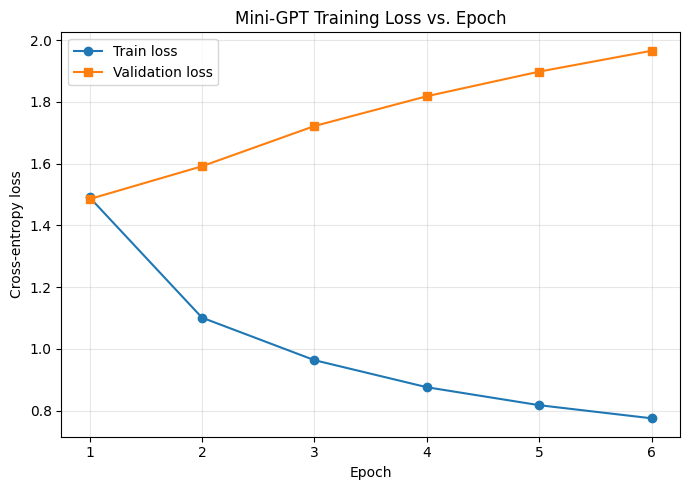

In [13]:
# Plot training (and validation) loss vs. epoch
plt.figure(figsize=(7, 5))
epochs_range = range(1, EPOCHS + 1)
plt.plot(epochs_range, train_loss_history, marker="o", label="Train loss")
plt.plot(epochs_range, val_loss_history, marker="s", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Mini-GPT Training Loss vs. Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()


## Part 4 — Sampling / Decoding Strategies



In [18]:
PROMPT = "ROMEO:"
GEN_LENGTH = 300  # number of new characters to generate

prompt_ids = torch.tensor([encode(PROMPT)], dtype=torch.long, device=device)

def show_generation(title, out_ids):
    generated = decode(out_ids[0].tolist())
    print(f"=== {title} ===")
    print(generated)
    print()


In [15]:
# 1) Greedy decoding
torch.manual_seed(SEED)
greedy_out = model.generate(prompt_ids, max_new_tokens=GEN_LENGTH, greedy=True)
show_generation("Greedy decoding", greedy_out)


=== Greedy decoding ===
ROMEO:
I am too sore unwise.

JULIET:
A rhy piteous poor is but effected with him.

Nurse:
Marry, sir, by'r lady, sir.

JULIET:
O God, I dance, and he is set and forth it!

Nurse:
Marry, say nothing; I will come to know you as near.

CAPULET:
Go, truly, go to;
The crown is at hand: I'll swear it; and so, 



In [16]:
# 2) Temperature sampling — 3 temperatures chosen to show clearly different behavior
temperatures = [0.3, 0.8, 1.5]   # low (conservative) -> medium -> high (very random)

for T in temperatures:
    torch.manual_seed(SEED)
    out = model.generate(prompt_ids, max_new_tokens=GEN_LENGTH, temperature=T, greedy=False)
    show_generation(f"Temperature sampling (T={T})", out)


=== Temperature sampling (T=0.3) ===
ROMEO:
Alack, what love can I not?

BENVOLIO:
Ay, ay, a scratch; marry, 'tis enough.

ROMEO:
What is that, what? mark you?

MERCUTIO:
Nay, an of them?

Nurse:
No, if this world--

MERCUTIO:
Thou dost mark me.

ROMEO:
Ay, sir, if my heart is dead.

MERCUTIO:
And the favours where the gentleman is rare
prep

=== Temperature sampling (T=0.8) ===
ROMEO:
Alack, what comfort is that Richmond was cursed by this feast,
Should be held and circumstance.

FRIAR LAURENCE:
Romeo, come, away; where are you made with the fire
Of the mildness of overty thousand men
Do reign me a life: no life, but kiss thy hands
And yet thy kindness, thou dost mark it not;
Th

=== Temperature sampling (T=1.5) ===
ROMEO:
Yet bake now, wilful be obstination!
Alack, eyes, O, noble Ya, nurse, by me use.
Then backdel-haared way, I cannot acquaint;
But for that, I can smile, will beg if thou hast;
For think'st thou in me noison to be self:
Thy will thus conceives? O, like all,
Yet let me

In [17]:
# 3) Top-k sampling — 2 values of k chosen to show clearly different diversity
top_k_values = [5, 40]   # small k -> conservative/focused, large k -> more diverse

for k in top_k_values:
    torch.manual_seed(SEED)
    out = model.generate(prompt_ids, max_new_tokens=GEN_LENGTH, temperature=1.0, top_k=k, greedy=False)
    show_generation(f"Top-k sampling (k={k})", out)


=== Top-k sampling (k=5) ===
ROMEO:
Alack, perjured and damnable!

Nurse:
O lady! O that I can say no.

JULIET:
O cousin! O woe! O sir, sweet Juliet,
Thy beauty hath made me steal these mercy.

JULIET:
It is not thy will, but and when next is noble
Of what is left us: he will stand and show 'em
As mine own all I play'd:
I never speak

=== Top-k sampling (k=40) ===
ROMEO:
Alack, Romeo! what bloody Richard!

Nurse:
And now art thou alack, and thy power thee by
The alone, and thy assault, thy kingdom stands title in.

JOHN OF GAUNT:
The Earl of Warwick, to be Peter French
And shallow last thou feeliver content?
As I bethink, yet let me not die,
If I be gore would thee

